## P605 – Hourly Energy Consumption Forecast

### 1. Business Understanding

## Business Objective:
### The objective of this project is to analyze historical hourly energy consumption data from PJM and identify important patterns and trends in electricity consumption.
### The project aims to:

### - Analyze hourly, daily, weekly, and seasonal energy consumption patterns.
### - Understand how energy consumption changes during holidays and weekends.
### - Study long-term trends in energy consumption.
### - Build a forecasting model using historical energy consumption data.
### - Evaluate the model using the last year's data as the test set.
### - Forecast hourly energy consumption for the next 30 days.


## 2.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 3.Load Dataset

In [2]:
df = pd.read_excel("PJMW_MW_Hourly.xlsx")
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [3]:
df.tail()

,Datetime,PJMW_MW
143201,2018-01-01 20:00:00,8401
143202,2018-01-01 21:00:00,8373
143203,2018-01-01 22:00:00,8238
143204,2018-01-01 23:00:00,7958
143205,2018-01-02 00:00:00,7691


## 4. Data Understanding:
### In this section, we will understand the structure, size, data types, and statistical characteristics of the dataset.

In [4]:
df.shape

(143206, 2)

In [5]:
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [7]:
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


## 5. Data Cleaning and Datetime Preparation
### ->The `Datetime` column represents the date and time of each energy consumption observation.
### -> We will convert it into Pandas datetime format and check for missing values and duplicate records.

## 5.1 — Convert Datetime

In [8]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.dtypes

Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object

## 5.2 — Missing Values

In [9]:
df.isnull().sum()

Datetime    0
PJMW_MW     0
dtype: int64

## 5.3 — Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

## 5.4 — Duplicate Datetime

In [11]:
df['Datetime'].duplicated().sum()

np.int64(4)

In [12]:
duplicate_times = df[df['Datetime'].duplicated(keep=False)].sort_values('Datetime')
duplicate_times

,Datetime,PJMW_MW
104424,2014-11-02 02:00:00,4613
104425,2014-11-02 02:00:00,4571
113208,2015-11-01 02:00:00,3927
113209,2015-11-01 02:00:00,3832
121848,2016-11-06 02:00:00,4114
121849,2016-11-06 02:00:00,4089
130656,2017-11-05 02:00:00,4042
130657,2017-11-05 02:00:00,3984


## Duplicate Timestamp Observation
### ->The dataset contains repeated timestamps for the 2:00 AM hour on certain dates.
### ->These repeated timestamps occur during the daylight saving time transition, when the same hour is recorded twice. The corresponding energy consumption values are different, indicating that these are valid observations rather than exact duplicate records.
### ->Therefore, these records are retained and are not removed as duplicate data.

In [13]:
print("Start Date:", df['Datetime'].min())
print("End Date:", df['Datetime'].max())
print("Total Rows:", len(df))

Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00
Total Rows: 143206


## 5.5 — Sort by Time

In [14]:
df = df.sort_values('Datetime').reset_index(drop=True)

In [15]:
df.head()

,Datetime,PJMW_MW
0,2002-04-01 01:00:00,4374
1,2002-04-01 02:00:00,4306
2,2002-04-01 03:00:00,4322
3,2002-04-01 04:00:00,4359
4,2002-04-01 05:00:00,4436


## 6. Check Hourly Data Continuity
### Since this is an hourly energy consumption dataset, we need to verify whether the timestamps are continuous and identify any missing hourly observations.

In [16]:
# Sort the data by datetime
df = df.sort_values('Datetime').reset_index(drop=True)
# Calculate the difference between consecutive timestamps
time_diff = df['Datetime'].diff()
# Check the most common time difference
time_diff.value_counts().head()

Datetime
0 days 01:00:00    143171
0 days 02:00:00        30
0 days 00:00:00         4
Name: count, dtype: int64

In [17]:
# Find intervals that are not exactly 1 hour
non_hourly = df[time_diff != pd.Timedelta(hours=1)]
non_hourly[['Datetime', 'PJMW_MW']].head(20)

,Datetime,PJMW_MW
0,2002-04-01 01:00:00,4374
146,2002-04-07 04:00:00,4871
5016,2002-10-27 03:00:00,4014
8880,2003-04-06 04:00:00,4376
13750,2003-10-26 03:00:00,4027
17614,2004-04-04 04:00:00,4691
22652,2004-10-31 03:00:00,4006
26348,2005-04-03 04:00:00,5026
31386,2005-10-30 03:00:00,4673
35082,2006-04-02 04:00:00,3721


## 6.1 — To identify Actual gaps only

In [18]:
# Calculate difference between consecutive timestamps
time_diff = df['Datetime'].diff()
# Keep only gaps greater than 1 hour
gaps = df[time_diff > pd.Timedelta(hours=1)].copy()
# Add the time gap
gaps['Gap'] = time_diff[time_diff > pd.Timedelta(hours=1)]
gaps[['Datetime', 'Gap']].head(20)

,Datetime,Gap
146,2002-04-07 04:00:00,0 days 02:00:00
5016,2002-10-27 03:00:00,0 days 02:00:00
8880,2003-04-06 04:00:00,0 days 02:00:00
13750,2003-10-26 03:00:00,0 days 02:00:00
17614,2004-04-04 04:00:00,0 days 02:00:00
22652,2004-10-31 03:00:00,0 days 02:00:00
26348,2005-04-03 04:00:00,0 days 02:00:00
31386,2005-10-30 03:00:00,0 days 02:00:00
35082,2006-04-02 04:00:00,0 days 02:00:00
40120,2006-10-29 03:00:00,0 days 02:00:00


In [19]:
len(gaps)

30

In [20]:
gaps['Gap'].value_counts()

Gap
0 days 02:00:00    30
Name: count, dtype: int64

In [21]:
gaps[['Datetime', 'Gap']]

,Datetime,Gap
146,2002-04-07 04:00:00,0 days 02:00:00
5016,2002-10-27 03:00:00,0 days 02:00:00
8880,2003-04-06 04:00:00,0 days 02:00:00
13750,2003-10-26 03:00:00,0 days 02:00:00
17614,2004-04-04 04:00:00,0 days 02:00:00
22652,2004-10-31 03:00:00,0 days 02:00:00
26348,2005-04-03 04:00:00,0 days 02:00:00
31386,2005-10-30 03:00:00,0 days 02:00:00
35082,2006-04-02 04:00:00,0 days 02:00:00
40120,2006-10-29 03:00:00,0 days 02:00:00


## 7. Exploratory Data Analysis (EDA)

## 7.1 Distribution of Energy Consumption
### We will examine the distribution of hourly energy consumption values to understand the typical consumption range and identify unusually high or low values.

In [22]:
df['PJMW_MW'].describe()

count    143206.000000
mean       5602.375089
std         979.142872
min         487.000000
25%        4907.000000
50%        5530.000000
75%        6252.000000
max        9594.000000
Name: PJMW_MW, dtype: float64

## Histogram

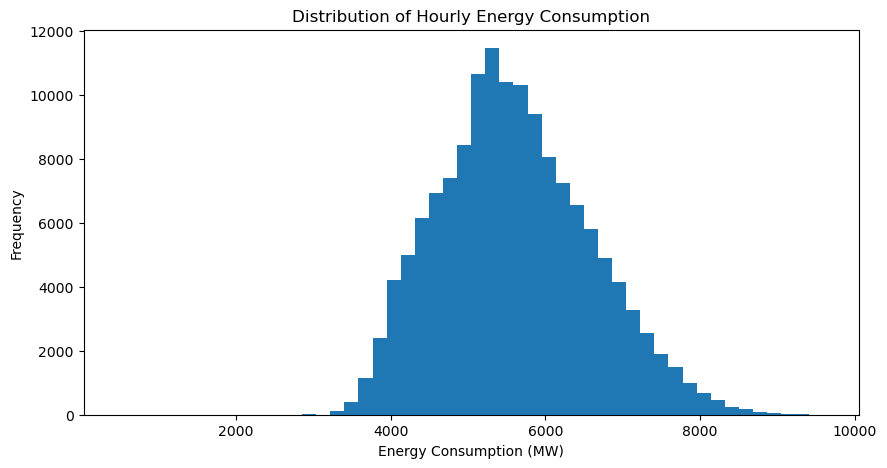

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(df['PJMW_MW'], bins=50)

plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Hourly Energy Consumption')

plt.show()

### EDA Insight:The distribution of hourly energy consumption is concentrated mainly between approximately 4,000 MW and 7,000 MW.Most observations are centered around 5,000–6,000 MW. Very low and very high consumption values occur less frequently. The distribution is approximately bell-shaped but shows some right skewness due to higher consumption values.

## 8. Hourly Energy Consumption Pattern
### We will analyze how energy consumption changes across different hours of the day.

In [24]:
df['Hour'] = df['Datetime'].dt.hour
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()
hourly_avg

Hour
0     5230.368359
1     4940.489276
2     4779.152349
3     4697.121996
4     4672.537366
5     4734.933479
6     4958.209450
7     5323.434316
8     5571.168398
9     5708.667058
10    5818.219169
11    5904.120476
12    5947.523794
13    5959.946716
14    5970.935824
15    5953.164712
16    5957.636394
17    6031.231233
18    6158.806803
19    6199.285355
20    6183.568365
21    6152.210121
22    5982.300436
23    5618.226206
Name: PJMW_MW, dtype: float64

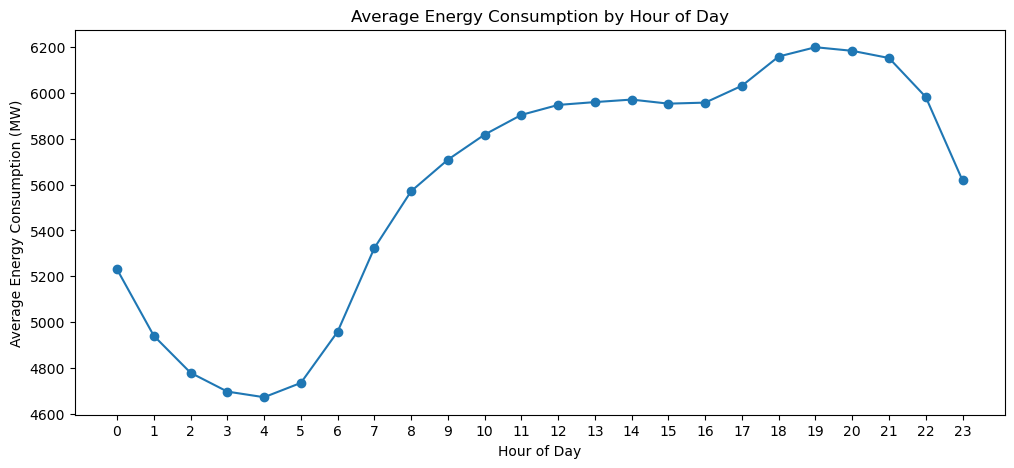

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Hour of Day')
plt.xticks(range(24))
plt.show()

## EDA Insight
### The hourly energy consumption shows a clear daily pattern.

### - Energy consumption is relatively low during the early morning hours, with the lowest average values occurring around 3–4 AM.
### - Consumption starts increasing from the early morning and rises significantly between 6 AM and 10 AM.
### - Consumption remains relatively high during the afternoon.
### - The highest average consumption occurs around 7 PM.
### - After the evening peak, consumption gradually decreases during the late evening.
### This indicates that the hour of the day is an important factor for forecasting energy consumption.

In [26]:
df['DayOfWeek'] = df['Datetime'].dt.day_name()
daily_avg = df.groupby('DayOfWeek')['PJMW_MW'].mean()
daily_avg

DayOfWeek
Friday       5686.839202
Monday       5700.518783
Saturday     5293.999413
Sunday       5149.638300
Thursday     5780.841051
Tuesday      5801.076837
Wednesday    5802.370701
Name: PJMW_MW, dtype: float64

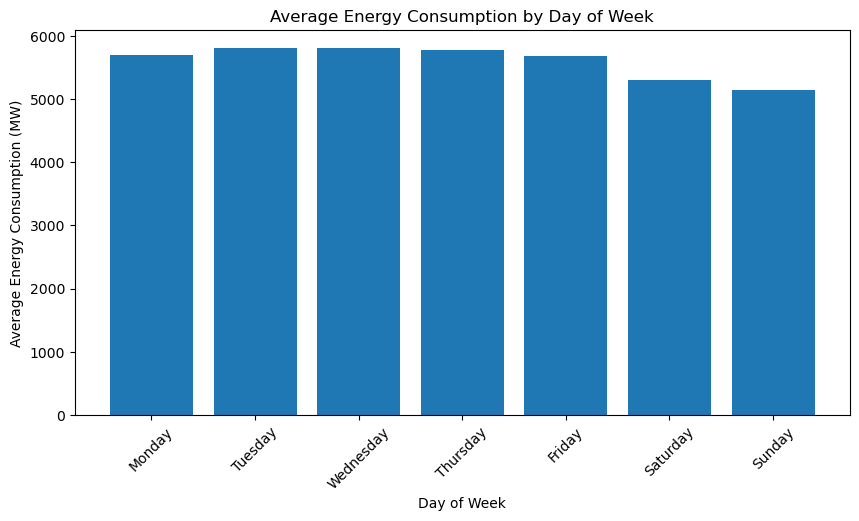

In [27]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_avg = daily_avg.reindex(day_order)

plt.figure(figsize=(10, 5))

plt.bar(daily_avg.index, daily_avg.values)

plt.xlabel('Day of Week')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Day of Week')

plt.xticks(rotation=45)

plt.show()

### EDA Insight

### Energy consumption varies across the days of the week.

### - Average consumption is generally higher on weekdays than on weekends.
### - Wednesday has the highest average consumption at approximately 5,802 MW.
### - Sunday has the lowest average consumption at approximately 5,150 MW.
### - Weekend consumption is noticeably lower than weekday consumption.
### This indicates that the day of the week is an important feature for forecasting energy consumption.

## 9 — Monthly Energy Consumption Pattern

In [28]:
df['Month'] = df['Datetime'].dt.month
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()
monthly_avg

Month
1     6447.667759
2     6296.808813
3     5654.097376
4     5022.310855
5     5015.845746
6     5516.756046
7     5861.537081
8     5822.142809
9     5205.872049
10    4997.642155
11    5403.630372
12    6064.431236
Name: PJMW_MW, dtype: float64

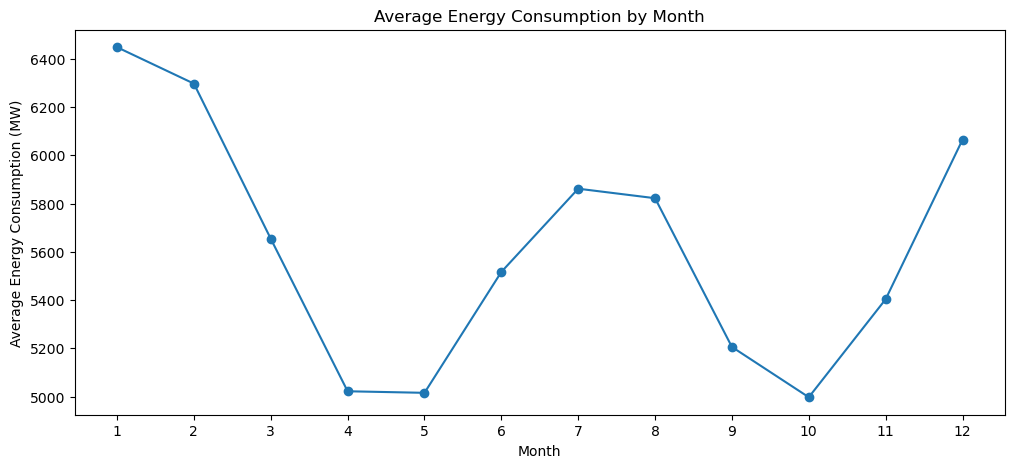

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Month')
plt.xticks(range(1, 13))
plt.show()

## EDA Insight
### The monthly analysis shows a clear seasonal variation in energy consumption.

### - January has the highest average energy consumption, at approximately 6,450 MW.
### - April and May have relatively low average consumption, around 5,000 MW.
### - Energy consumption increases during July and August to around 5,800 MW.
### - Consumption decreases again during September and October.
### - Consumption rises during November and December, with December reaching approximately 6,060 MW.
### Overall, the data shows that energy consumption varies significantly across different months of the year. Therefore, month/season is an important factor for energy consumption forecasting.

## 10-Season pattern

In [30]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

df[['Datetime', 'Month', 'Season', 'PJMW_MW']].head()

,Datetime,Month,Season,PJMW_MW
0,2002-04-01 01:00:00,4,Spring,4374
1,2002-04-01 02:00:00,4,Spring,4306
2,2002-04-01 03:00:00,4,Spring,4322
3,2002-04-01 04:00:00,4,Spring,4359
4,2002-04-01 05:00:00,4,Spring,4436


In [31]:
season_avg = df.groupby('Season')['PJMW_MW'].mean()
season_avg

Season
Autumn    5200.143147
Spring    5224.394790
Summer    5734.206129
Winter    6268.813851
Name: PJMW_MW, dtype: float64

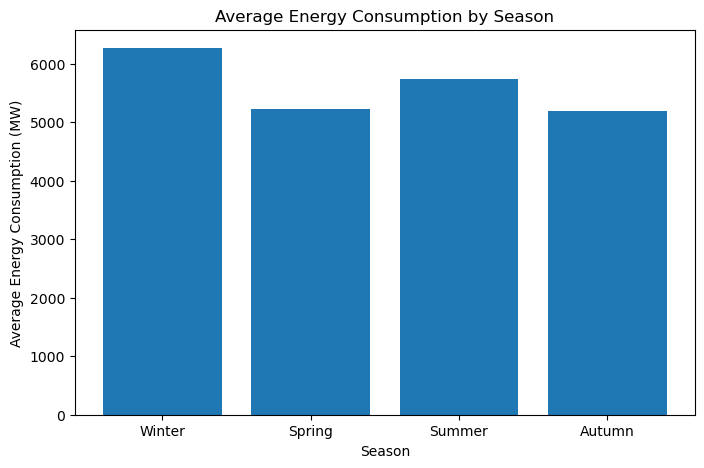

In [32]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

season_avg = season_avg.reindex(season_order)

plt.figure(figsize=(8, 5))

plt.bar(season_avg.index, season_avg.values)

plt.xlabel('Season')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Season')

plt.show()

### EDA Insight
### The seasonal analysis shows significant variation in energy consumption.
### - Winter has the highest average energy consumption at approximately 6,269 MW.
### - Summer has the second-highest average consumption at approximately 5,734 MW.
### - Spring and Autumn have lower average consumption, at approximately 5,224 MW and 5,200 MW respectively.
### - The average consumption difference between Winter and Summer is approximately 535 MW.
### This confirms that seasonality is an important factor in the PJM energy consumption data and should be considered during forecasting.

## 10 — Hourly Pattern by Season

In [33]:
season_hourly = df.groupby(['Season', 'Hour'])['PJMW_MW'].mean()
season_hourly

Season  Hour
Autumn  0       4806.136676
        1       4545.118819
        2       4403.227210
        3       4333.835852
        4       4317.000000
                   ...     
Winter  19      6863.181440
        20      6851.971607
        21      6769.177978
        22      6569.740305
        23      6255.604571
Name: PJMW_MW, Length: 96, dtype: float64

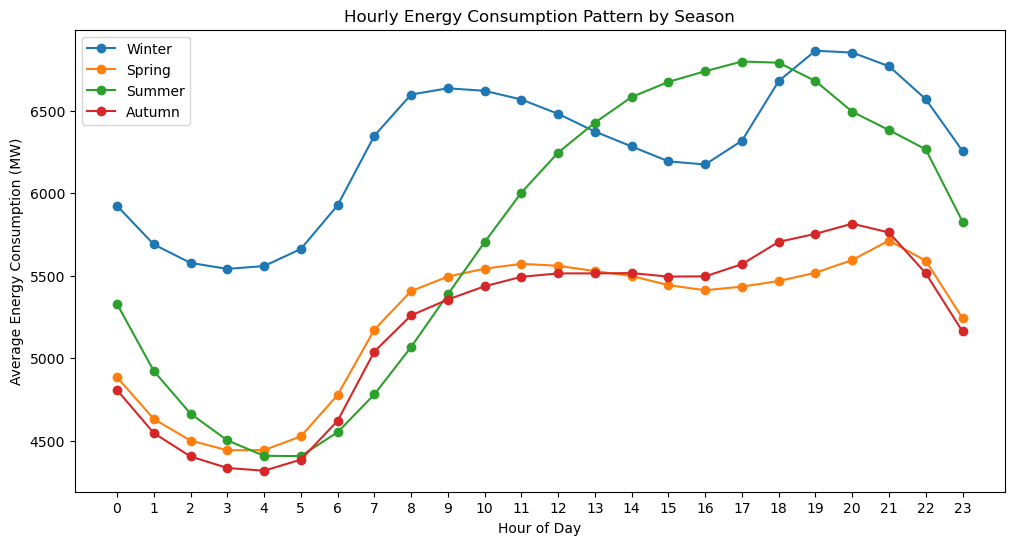

In [34]:
plt.figure(figsize=(12, 6))

for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    plt.plot(
        range(24),
        season_hourly.loc[season],
        marker='o',
        label=season
    )

plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Hourly Energy Consumption Pattern by Season')
plt.xticks(range(24))
plt.legend()

plt.show()

### EDA Insight – Seasonal Hourly Pattern
### The hourly energy consumption pattern differs across seasons.
### - Winter has the highest overall consumption and shows strong increases during the morning and evening hours.
### - Summer also shows a strong increase during the daytime, with high consumption during the afternoon and evening.
### - Spring and Autumn generally have lower consumption levels compared with Winter and Summer.
### - The hourly consumption curves are not identical across seasons, indicating that the relationship between hour of day and energy consumption changes depending on the season.
### Therefore, both time-of-day and seasonal information are important features for forecasting energy consumption.

## 11 — Yearly Trend

In [35]:
df['Year'] = df['Datetime'].dt.year
yearly_avg = df.groupby('Year')['PJMW_MW'].mean()
yearly_avg

Year
2002    5621.663180
2003    5700.628226
2004    5866.616602
2005    6038.406029
2006    5425.448847
2007    5635.396780
2008    5530.132544
2009    5290.557433
2010    5573.025351
2011    5509.640215
2012    5395.010818
2013    5556.783626
2014    5656.334132
2015    5620.985616
2016    5577.929531
2017    5500.184361
2018    5848.157516
Name: PJMW_MW, dtype: float64

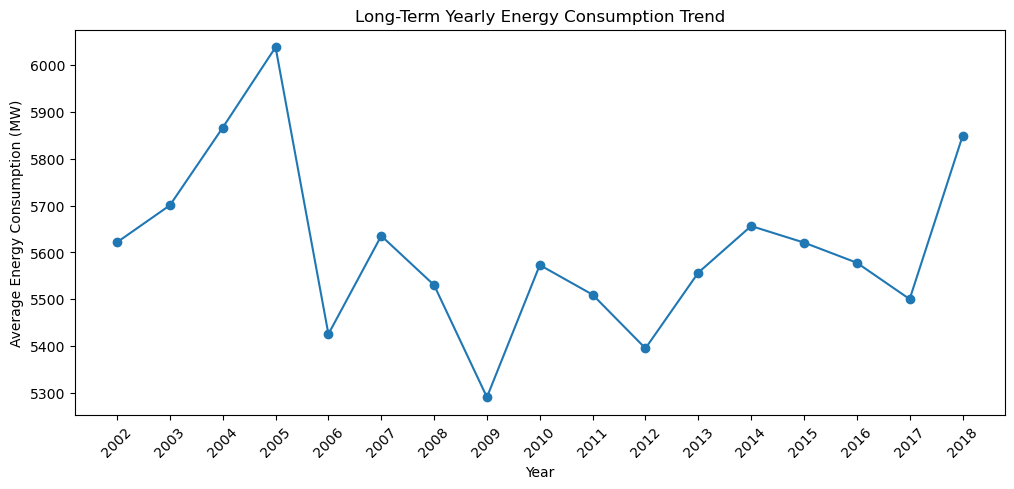

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Long-Term Yearly Energy Consumption Trend')
plt.xticks(yearly_avg.index, rotation=45)
plt.show()

### EDA Insight – Long-Term Trend
### The yearly average energy consumption shows considerable variation over the observation period.
### - Energy consumption increased between 2002 and 2005.
### - A decline was observed from 2006 to 2009, with 2009 having the lowest yearly average.
### - Consumption recovered after 2009 but continued to fluctuate between years.
### - A noticeable increase occurred in 2018.
### Overall, the yearly averages do not show a simple monotonic trend. Long-term consumption varies across years, and changes in the PJM regional data coverage should also be considered when interpreting these yearly differences.

## 12 — Holiday Analysis

In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()

holidays = cal.holidays(
    start=df['Datetime'].min(),
    end=df['Datetime'].max()
)

holidays[:10]

DatetimeIndex(['2002-05-27', '2002-07-04', '2002-09-02', '2002-10-14',
               '2002-11-11', '2002-11-28', '2002-12-25', '2003-01-01',
               '2003-01-20', '2003-02-17'],
              dtype='datetime64[ns]', freq=None)

In [38]:
df['IsHoliday'] = df['Datetime'].dt.normalize().isin(holidays)

df.groupby('IsHoliday')['PJMW_MW'].mean()

IsHoliday
False    5604.746436
True     5517.403035
Name: PJMW_MW, dtype: float64

### Which specific holidays have higher/lower energy consumption?

In [39]:
holiday_dates = cal.holidays(
    start=df['Datetime'].min(),
    end=df['Datetime'].max(),
    return_name=True
)

holiday_dates.head(10)

2002-05-27                           Memorial Day
2002-07-04                       Independence Day
2002-09-02                              Labor Day
2002-10-14                           Columbus Day
2002-11-11                           Veterans Day
2002-11-28                       Thanksgiving Day
2002-12-25                          Christmas Day
2003-01-01                         New Year's Day
2003-01-20    Birthday of Martin Luther King, Jr.
2003-02-17                  Washington's Birthday
dtype: object

## 12.1 — Holiday Name column create

In [40]:
holiday_map = holiday_dates.to_dict()
df['HolidayName'] = df['Datetime'].dt.normalize().map(holiday_map)
df[['Datetime', 'PJMW_MW', 'HolidayName']].dropna().head(10)

,Datetime,PJMW_MW,HolidayName
1342,2002-05-27 00:00:00,4307,Memorial Day
1343,2002-05-27 01:00:00,4023,Memorial Day
1344,2002-05-27 02:00:00,3871,Memorial Day
1345,2002-05-27 03:00:00,3801,Memorial Day
1346,2002-05-27 04:00:00,3745,Memorial Day
1347,2002-05-27 05:00:00,3712,Memorial Day
1348,2002-05-27 06:00:00,3728,Memorial Day
1349,2002-05-27 07:00:00,3797,Memorial Day
1350,2002-05-27 08:00:00,3986,Memorial Day
1351,2002-05-27 09:00:00,4358,Memorial Day


## 12.2 — Holiday-wise average

In [41]:
holiday_avg = (
    df.dropna(subset=['HolidayName'])
      .groupby('HolidayName')['PJMW_MW']
      .mean()
      .sort_values(ascending=False)
)

holiday_avg

HolidayName
Birthday of Martin Luther King, Jr.    6713.906250
Washington's Birthday                  6538.367188
New Year's Day                         5711.768229
Veterans Day                           5415.606771
Christmas Day                          5402.072917
Independence Day                       5321.200980
Columbus Day                           5122.265625
Thanksgiving Day                       5110.158854
Labor Day                              5012.890625
Memorial Day                           4878.017157
Name: PJMW_MW, dtype: float64

## 12.3 — check Number of observations

In [42]:
holiday_summary = (
    df.dropna(subset=['HolidayName'])
      .groupby('HolidayName')['PJMW_MW']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
)

holiday_summary

,mean,count
HolidayName,,
"Birthday of Martin Luther King, Jr.",6713.906250,384
Washington's Birthday,6538.367188,384
New Year's Day,5711.768229,384
Veterans Day,5415.606771,384
Christmas Day,5402.072917,384
Independence Day,5321.200980,408
Columbus Day,5122.265625,384
Thanksgiving Day,5110.158854,384
Labor Day,5012.890625,384


## 13 — Outlier Analysis

## 13.1 Boxplot

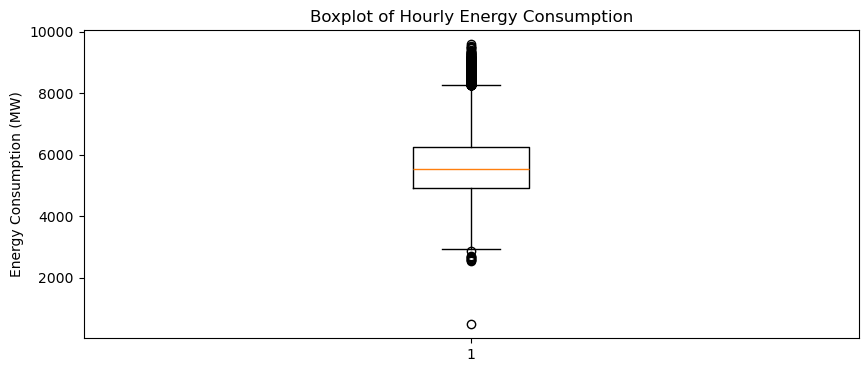

In [43]:
plt.figure(figsize=(10, 4))

plt.boxplot(df['PJMW_MW'])

plt.ylabel('Energy Consumption (MW)')
plt.title('Boxplot of Hourly Energy Consumption')

plt.show()

In [44]:
Q1 = df['PJMW_MW'].quantile(0.25)
Q3 = df['PJMW_MW'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['PJMW_MW'] < lower_bound) |
    (df['PJMW_MW'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Potential Outliers:", len(outliers))

Lower Bound: 2889.5
Upper Bound: 8269.5
Number of Potential Outliers: 703


In [45]:
outliers[['Datetime', 'PJMW_MW']].head(20)

,Datetime,PJMW_MW
2703,2002-07-22 17:00:00,8300
2872,2002-07-29 18:00:00,8270
7143,2003-01-23 18:00:00,8296
7144,2003-01-23 19:00:00,8431
7145,2003-01-23 20:00:00,8437
7146,2003-01-23 21:00:00,8333
10148,2003-05-29 00:00:00,487
15892,2004-01-23 09:00:00,8289
23857,2004-12-20 08:00:00,8417
23858,2004-12-20 09:00:00,8478


In [46]:
low_outliers = df[df['PJMW_MW'] < lower_bound]
high_outliers = df[df['PJMW_MW'] > upper_bound]

print("Low outliers:", len(low_outliers))
print("High outliers:", len(high_outliers))

Low outliers: 10
High outliers: 693


In [47]:
low_outliers[['Datetime', 'PJMW_MW']]

,Datetime,PJMW_MW
10148,2003-05-29 00:00:00,487
87662,2012-04-01 13:00:00,2878
87663,2012-04-01 14:00:00,2721
87664,2012-04-01 15:00:00,2663
87665,2012-04-01 16:00:00,2574
87666,2012-04-01 17:00:00,2586
87667,2012-04-01 18:00:00,2600
87668,2012-04-01 19:00:00,2630
87672,2012-04-01 23:00:00,2690
87673,2012-04-02 00:00:00,2553


In [48]:
high_outliers[['Datetime', 'PJMW_MW']].head(20)

,Datetime,PJMW_MW
2703,2002-07-22 17:00:00,8300
2872,2002-07-29 18:00:00,8270
7143,2003-01-23 18:00:00,8296
7144,2003-01-23 19:00:00,8431
7145,2003-01-23 20:00:00,8437
7146,2003-01-23 21:00:00,8333
15892,2004-01-23 09:00:00,8289
23857,2004-12-20 08:00:00,8417
23858,2004-12-20 09:00:00,8478
23859,2004-12-20 10:00:00,8366


In [49]:
high_outliers.nlargest(20, 'PJMW_MW')[['Datetime', 'PJMW_MW']]

,Datetime,PJMW_MW
112974,2015-02-20 08:00:00,9594
112962,2015-02-19 20:00:00,9536
112973,2015-02-20 07:00:00,9512
112961,2015-02-19 19:00:00,9489
112975,2015-02-20 09:00:00,9481
112963,2015-02-19 21:00:00,9424
113070,2015-02-24 08:00:00,9366
103170,2014-01-07 20:00:00,9349
138186,2018-01-05 20:00:00,9342
138185,2018-01-05 19:00:00,9325


## 14 — Correlation Heatmap

In [50]:
df['DayOfWeekNum'] = df['Datetime'].dt.dayofweek

In [51]:
df['Day'] = df['Datetime'].dt.day
df['DayOfWeekNum'] = df['Datetime'].dt.dayofweek

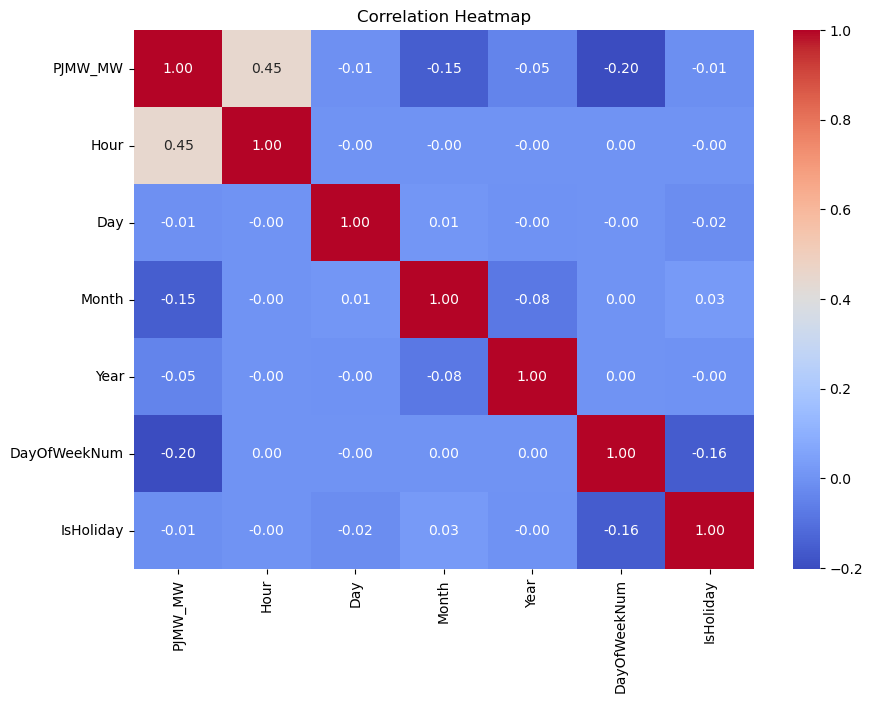

In [52]:
import seaborn as sns

corr = df[
    ['PJMW_MW', 'Hour', 'Day', 'Month', 'Year', 'DayOfWeekNum', 'IsHoliday']
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### EDA Insight – Correlation Analysis
### The correlation heatmap shows that Hour has the strongest linear relationship with energy consumption among the analyzed features, with a correlation of approximately 0.45.
### DayOfWeekNum and Month show weaker negative relationships with energy consumption, while Year and Day have very weak linear relationships.
### The correlation between IsHoliday and energy consumption is close to zero. However, earlier holiday analysis showed a difference between average holiday and non-holiday consumption. Therefore, correlation alone does not fully capture the effect of categorical and seasonal factors.

### Overall, the heatmap supports the importance of time-based features, but it should be interpreted together with the other EDA analyses.

In [53]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

print("Start Date:", df['Datetime'].min())
print("End Date:", df['Datetime'].max())

Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


In [54]:
test_start = df['Datetime'].max() - pd.DateOffset(years=1)

train = df[df['Datetime'] < test_start].copy()
test = df[df['Datetime'] >= test_start].copy()

print("Train:", train.shape)
print("Test :", test.shape)

print("Train period:", train['Datetime'].min(), "to", train['Datetime'].max())
print("Test period :", test['Datetime'].min(), "to", test['Datetime'].max())

Train: (134445, 11)
Test : (8761, 11)
Train period: 2002-04-01 01:00:00 to 2017-08-02 23:00:00
Test period : 2017-08-03 00:00:00 to 2018-08-03 00:00:00


In [55]:
train_ts = train.set_index('Datetime')['PJMW_MW']
test_ts = test.set_index('Datetime')['PJMW_MW']

### Step 2 — Seasonal Naive Prediction

In [56]:
seasonal_period = 24
full_series = df.set_index('Datetime')['PJMW_MW']
seasonal_naive_pred = full_series.shift(seasonal_period).loc[test_ts.index]

### Step 3 — Actual vs Predicted check

In [57]:
sn_df = (
    df.groupby('Datetime', as_index=False)['PJMW_MW']
      .mean()
      .sort_values('Datetime')
)

In [58]:
print("Rows:", len(sn_df))
print("Duplicate timestamps:", sn_df['Datetime'].duplicated().sum())

Rows: 143202
Duplicate timestamps: 0


In [59]:
test_start = df['Datetime'].max() - pd.DateOffset(years=1)

sn_train = sn_df[sn_df['Datetime'] < test_start].copy()
sn_test = sn_df[sn_df['Datetime'] >= test_start].copy()

print("Train:", sn_train.shape)
print("Test :", sn_test.shape)

print("Train period:", sn_train['Datetime'].min(), "to", sn_train['Datetime'].max())
print("Test period :", sn_test['Datetime'].min(), "to", sn_test['Datetime'].max())

Train: (134442, 2)
Test : (8760, 2)
Train period: 2002-04-01 01:00:00 to 2017-08-02 23:00:00
Test period : 2017-08-03 00:00:00 to 2018-08-03 00:00:00


In [60]:
sn_series = sn_df.set_index('Datetime')['PJMW_MW']

seasonal_naive_pred = sn_series.shift(24).reindex(
    sn_test['Datetime']
)

In [61]:
result = pd.DataFrame({
    'Actual': sn_test.set_index('Datetime')['PJMW_MW'],
    'Predicted': seasonal_naive_pred.values
})

result.head(30)

,Actual,Predicted
Datetime,,
2017-08-03 00:00:00,5591.0,5536.0
2017-08-03 01:00:00,5170.0,5207.0
2017-08-03 02:00:00,4948.0,4871.0
2017-08-03 03:00:00,4700.0,4692.0
2017-08-03 04:00:00,4606.0,4614.0
2017-08-03 05:00:00,4580.0,4624.0
2017-08-03 06:00:00,4797.0,4734.0
2017-08-03 07:00:00,5030.0,4982.0
2017-08-03 08:00:00,5322.0,5245.0


## Seasonal Naive Evaluation

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = result['Actual']
predicted = result['Predicted']

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("Seasonal Naive Results")
print("----------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

Seasonal Naive Results
----------------------
MAE  : 382.6808219178082
RMSE : 501.35142524797266
MAPE : 6.663335868299662 %


In [63]:
seasonal_naive_results = {
    'Model': 'Seasonal Naive',
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape
}

seasonal_naive_results

{'Model': 'Seasonal Naive',
 'MAE': 382.6808219178082,
 'RMSE': np.float64(501.35142524797266),
 'MAPE': np.float64(6.663335868299662)}

## Step 4 — Holt-Winters Type 1

### Type 1 = Simple Exponential Smoothing

In [64]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [65]:
train_series = sn_train.set_index('Datetime')['PJMW_MW']
test_series = sn_test.set_index('Datetime')['PJMW_MW']

In [66]:
ses_model = SimpleExpSmoothing(
    train_series
).fit(optimized=True)

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [67]:
ses_pred = ses_model.forecast(len(test_series))

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [68]:
ses_result = pd.DataFrame({
    'Actual': test_series,
    'Predicted': ses_pred
})

ses_result.head(10)

,Actual,Predicted
2017-08-03 00:00:00,5591.0,NaN
2017-08-03 01:00:00,5170.0,NaN
2017-08-03 02:00:00,4948.0,NaN
2017-08-03 03:00:00,4700.0,NaN
2017-08-03 04:00:00,4606.0,NaN
2017-08-03 05:00:00,4580.0,NaN
2017-08-03 06:00:00,4797.0,NaN
2017-08-03 07:00:00,5030.0,NaN
2017-08-03 08:00:00,5322.0,NaN
2017-08-03 09:00:00,5602.0,NaN


In [69]:
ses_pred = ses_model.forecast(len(test_series))

ses_pred = pd.Series(
    ses_pred.to_numpy(),
    index=test_series.index
)

ses_result = pd.DataFrame({
    'Actual': test_series,
    'Predicted': ses_pred
})

ses_result.head(10)

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Actual,Predicted
Datetime,,
2017-08-03 00:00:00,5591.0,6250.000007
2017-08-03 01:00:00,5170.0,6250.000007
2017-08-03 02:00:00,4948.0,6250.000007
2017-08-03 03:00:00,4700.0,6250.000007
2017-08-03 04:00:00,4606.0,6250.000007
2017-08-03 05:00:00,4580.0,6250.000007
2017-08-03 06:00:00,4797.0,6250.000007
2017-08-03 07:00:00,5030.0,6250.000007
2017-08-03 08:00:00,5322.0,6250.000007


In [70]:
ses_actual = ses_result['Actual']
ses_predicted = ses_result['Predicted']

ses_mae = mean_absolute_error(ses_actual, ses_predicted)
ses_rmse = np.sqrt(mean_squared_error(ses_actual, ses_predicted))
ses_mape = np.mean(
    np.abs((ses_actual - ses_predicted) / ses_actual)
) * 100

print("Simple Exponential Smoothing Results")
print("------------------------------------")
print("MAE  :", ses_mae)
print("RMSE :", ses_rmse)
print("MAPE :", ses_mape, "%")

Simple Exponential Smoothing Results
------------------------------------
MAE  : 945.8931538222078
RMSE : 1135.1747496910587
MAPE : 18.26478167465524 %


In [71]:
ses_results = {
    'Model': 'Simple Exponential Smoothing',
    'MAE': ses_mae,
    'RMSE': ses_rmse,
    'MAPE': ses_mape
}

ses_results

{'Model': 'Simple Exponential Smoothing',
 'MAE': 945.8931538222078,
 'RMSE': np.float64(1135.1747496910587),
 'MAPE': np.float64(18.26478167465524)}

## Type 2: Holt's Linear Trend

In [72]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(
    train_series
).fit(optimized=True)

holt_pred = holt_model.forecast(len(test_series))

holt_pred = pd.Series(
    holt_pred.to_numpy(),
    index=test_series.index
)

holt_result = pd.DataFrame({
    'Actual': test_series,
    'Predicted': holt_pred
})

holt_result.head(10)

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Actual,Predicted
Datetime,,
2017-08-03 00:00:00,5591.0,5803.000008
2017-08-03 01:00:00,5170.0,5356.000013
2017-08-03 02:00:00,4948.0,4909.000018
2017-08-03 03:00:00,4700.0,4462.000023
2017-08-03 04:00:00,4606.0,4015.000028
2017-08-03 05:00:00,4580.0,3568.000033
2017-08-03 06:00:00,4797.0,3121.000039
2017-08-03 07:00:00,5030.0,2674.000044
2017-08-03 08:00:00,5322.0,2227.000049


In [73]:
holt_actual = holt_result['Actual']
holt_predicted = holt_result['Predicted']

holt_mae = mean_absolute_error(holt_actual, holt_predicted)
holt_rmse = np.sqrt(mean_squared_error(holt_actual, holt_predicted))
holt_mape = np.mean(
    np.abs((holt_actual - holt_predicted) / holt_actual)
) * 100

print("Holt's Linear Trend Results")
print("---------------------------")
print("MAE  :", holt_mae)
print("RMSE :", holt_rmse)
print("MAPE :", holt_mape, "%")

Holt's Linear Trend Results
---------------------------
MAE  : 1957534.5872950486
RMSE : 2260507.0800649654
MAPE : 34998.12851202742 %


In [74]:
holt_results = {
    'Model': "Holt's Linear Trend",
    'MAE': holt_mae,
    'RMSE': holt_rmse,
    'MAPE': holt_mape
}

holt_results

{'Model': "Holt's Linear Trend",
 'MAE': 1957534.5872950486,
 'RMSE': np.float64(2260507.0800649654),
 'MAPE': np.float64(34998.12851202742)}

## Type 3: Holt-Winters / Triple Exponential Smoothing

### Step 1 — Holt-Winters model

In [75]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=24
).fit(optimized=True)

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### Step 2 — Forecast

In [76]:
hw_pred = hw_model.forecast(len(test_series))

hw_pred = pd.Series(
    hw_pred.to_numpy(),
    index=test_series.index
)

C:\Users\aadha\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### tep 3 — Actual vs Predicted

In [77]:
hw_result = pd.DataFrame({
    'Actual': test_series,
    'Predicted': hw_pred
})

hw_result.head(24)

,Actual,Predicted
Datetime,,
2017-08-03 00:00:00,5591.0,5697.474710
2017-08-03 01:00:00,5170.0,5280.614546
2017-08-03 02:00:00,4948.0,4935.993827
2017-08-03 03:00:00,4700.0,4701.246905
2017-08-03 04:00:00,4606.0,4562.117492
2017-08-03 05:00:00,4580.0,4513.022466
2017-08-03 06:00:00,4797.0,4624.451627
2017-08-03 07:00:00,5030.0,4814.106728
2017-08-03 08:00:00,5322.0,5062.695016


### Step 4 — Calculate metrics

In [78]:
hw_actual = hw_result['Actual']
hw_predicted = hw_result['Predicted']

hw_mae = mean_absolute_error(hw_actual, hw_predicted)
hw_rmse = np.sqrt(mean_squared_error(hw_actual, hw_predicted))
hw_mape = np.mean(
    np.abs((hw_actual - hw_predicted) / hw_actual)
) * 100

print("Holt-Winters Results")
print("--------------------")
print("MAE  :", hw_mae)
print("RMSE :", hw_rmse)
print("MAPE :", hw_mape, "%")

Holt-Winters Results
--------------------
MAE  : 949.1081350093594
RMSE : 1177.032508668024
MAPE : 16.950369324562757 %


In [79]:
hw_results = {
    'Model': 'Holt-Winters',
    'MAE': hw_mae,
    'RMSE': hw_rmse,
    'MAPE': hw_mape
}

hw_results

{'Model': 'Holt-Winters',
 'MAE': 949.1081350093594,
 'RMSE': np.float64(1177.032508668024),
 'MAPE': np.float64(16.950369324562757)}

## Step 5 — All model results compare

In [80]:
model_comparison = pd.DataFrame([
    seasonal_naive_results,
    ses_results,
    holt_results,
    hw_results
])

model_comparison

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,3.826808e+02,5.013514e+02,6.663336
1,Simple Exponential Smoothing,9.458932e+02,1.135175e+03,18.264782
2,Holt's Linear Trend,1.957535e+06,2.260507e+06,34998.128512
3,Holt-Winters,9.491081e+02,1.177033e+03,16.950369


In [81]:
model_comparison.sort_values('MAE')

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,3.826808e+02,5.013514e+02,6.663336
1,Simple Exponential Smoothing,9.458932e+02,1.135175e+03,18.264782
3,Holt-Winters,9.491081e+02,1.177033e+03,16.950369
2,Holt's Linear Trend,1.957535e+06,2.260507e+06,34998.128512


In [82]:
model_comparison.sort_values('MAPE')

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,3.826808e+02,5.013514e+02,6.663336
3,Holt-Winters,9.491081e+02,1.177033e+03,16.950369
1,Simple Exponential Smoothing,9.458932e+02,1.135175e+03,18.264782
2,Holt's Linear Trend,1.957535e+06,2.260507e+06,34998.128512


In [83]:
full_series = sn_df.set_index('Datetime')['PJMW_MW']

print("Last available date:", full_series.index.max())
print("Total observations:", len(full_series))

Last available date: 2018-08-03 00:00:00
Total observations: 143202


### Next 30 days timestamps

In [84]:
future_dates = pd.date_range(
    start=full_series.index.max() + pd.Timedelta(hours=1),
    periods=720,
    freq='h'
)

print("Forecast start:", future_dates.min())
print("Forecast end  :", future_dates.max())
print("Total hours   :", len(future_dates))

Forecast start: 2018-08-03 01:00:00
Forecast end  : 2018-09-02 00:00:00
Total hours   : 720


### Seasonal Naive 30-day forecast

### Today's 10 AM → previous day's 10 AM value

In [85]:
# Last 24 hours of actual consumption
last_24_hours = full_series.iloc[-24:].values

# Repeat the last 24-hour pattern for 30 days
forecast_values = np.tile(last_24_hours, 30)

# Create future timestamps
future_dates = pd.date_range(
    start=full_series.index.max() + pd.Timedelta(hours=1),
    periods=720,
    freq='h'
)

# Create forecast dataframe
forecast_30_days = pd.DataFrame({
    'Datetime': future_dates,
    'Forecast_MW': forecast_values
})

forecast_30_days.head(24)

,Datetime,Forecast_MW
0,2018-08-03 01:00:00,5100.0
1,2018-08-03 02:00:00,4840.0
2,2018-08-03 03:00:00,4745.0
3,2018-08-03 04:00:00,4572.0
4,2018-08-03 05:00:00,4594.0
5,2018-08-03 06:00:00,4826.0
6,2018-08-03 07:00:00,5114.0
7,2018-08-03 08:00:00,5333.0
8,2018-08-03 09:00:00,5597.0
9,2018-08-03 10:00:00,5775.0


### Visualize the 30-day forecast

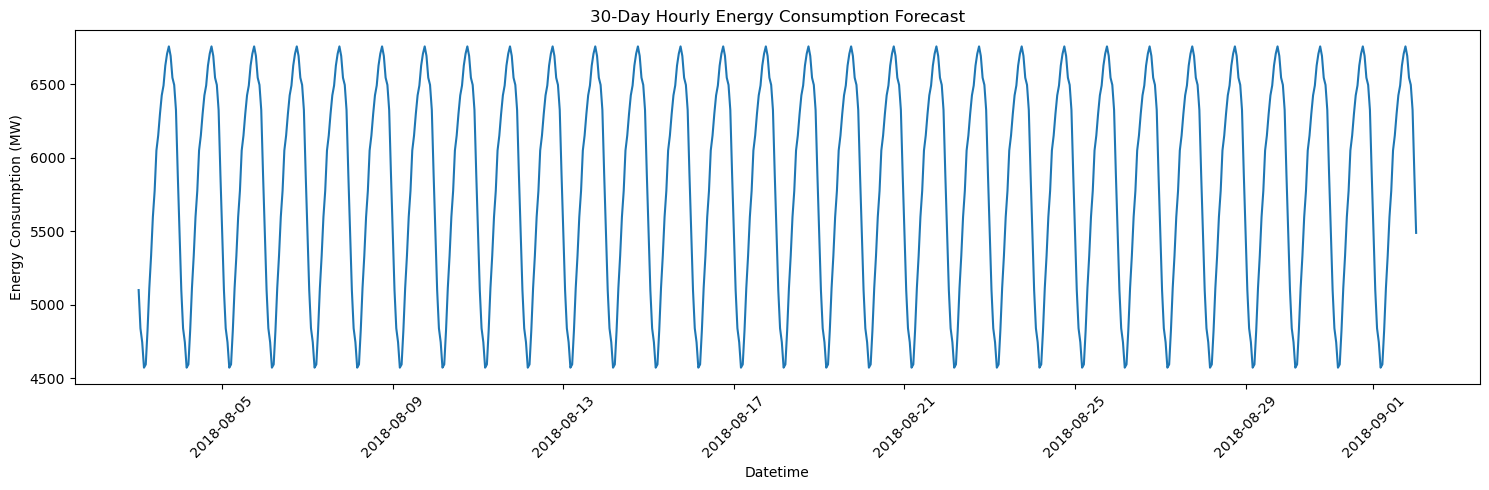

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    forecast_30_days['Datetime'],
    forecast_30_days['Forecast_MW']
)

plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title('30-Day Hourly Energy Consumption Forecast')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 30-day forecast Excel file ga save cheyyi

In [87]:
forecast_30_days.to_excel(
    'PJM_30_Day_Forecast.xlsx',
    index=False
)

print("Forecast file saved successfully.")

Forecast file saved successfully.


In [88]:
forecast_30_days.shape

(720, 2)

In [89]:
forecast_30_days.tail()

,Datetime,Forecast_MW
715,2018-09-01 20:00:00,6545.0
716,2018-09-01 21:00:00,6496.0
717,2018-09-01 22:00:00,6325.0
718,2018-09-01 23:00:00,5892.0
719,2018-09-02 00:00:00,5489.0


In [91]:
print("30-Day Forecast Summary")
print("-----------------------")
print("Forecast Start :", forecast_30_days['Datetime'].min())
print("Forecast End   :", forecast_30_days['Datetime'].max())
print("Total Hours    :", len(forecast_30_days))
print("Average MW     :", forecast_30_days['Forecast_MW'].mean())
print("Minimum MW     :", forecast_30_days['Forecast_MW'].min())
print("Maximum MW     :", forecast_30_days['Forecast_MW'].max())

30-Day Forecast Summary
-----------------------
Forecast Start : 2018-08-03 01:00:00
Forecast End   : 2018-09-02 00:00:00
Total Hours    : 720
Average MW     : 5810.291666666667
Minimum MW     : 4572.0
Maximum MW     : 6758.0


### We analyzed PJM hourly energy consumption data, performed EDA and identified strong daily, weekly and seasonal patterns. We compared four forecasting models. Seasonal Naive achieved the lowest test errors with a MAPE of 6.66%, so we used it as our baseline forecasting approach. Finally, we generated a 30-day forecast with 720 hourly predictions. This project demonstrates how time-series forecasting can support short-term electricity demand planning

## 15. Machine Learning Models — XGBoost & LightGBM 
### In this section we build two gradient boosting models, XGBoost and LightGBM, to forecast hourly energy consumption. Unlike the statistical models above, these models can learn non-linear relationships and use lag/rolling features built from past consumption.

### 15.1 — Feature Engineering
### We build time-based features (hour, day, month, year, day-of-week, holiday flag), cyclical (sin/cos) encodings of hour/month/day-of-week, and lag & rolling-window features from past consumption values.

In [93]:
ml_df = sn_df.copy()

ml_df['Hour'] = ml_df['Datetime'].dt.hour
ml_df['Day'] = ml_df['Datetime'].dt.day
ml_df['Month'] = ml_df['Datetime'].dt.month
ml_df['Year'] = ml_df['Datetime'].dt.year
ml_df['DayOfWeekNum'] = ml_df['Datetime'].dt.dayofweek
ml_df['IsHoliday'] = ml_df['Datetime'].dt.normalize().isin(holidays).astype(int)

# Cyclical (sin/cos) encoding so the model understands hour 23 is close to hour 0, Dec is close to Jan, etc.
ml_df['Hour_sin'] = np.sin(2 * np.pi * ml_df['Hour'] / 24)
ml_df['Hour_cos'] = np.cos(2 * np.pi * ml_df['Hour'] / 24)
ml_df['Month_sin'] = np.sin(2 * np.pi * ml_df['Month'] / 12)
ml_df['Month_cos'] = np.cos(2 * np.pi * ml_df['Month'] / 12)
ml_df['DayOfWeek_sin'] = np.sin(2 * np.pi * ml_df['DayOfWeekNum'] / 7)
ml_df['DayOfWeek_cos'] = np.cos(2 * np.pi * ml_df['DayOfWeekNum'] / 7)

ml_df.head()

,Datetime,PJMW_MW,Hour,Day,Month,Year,DayOfWeekNum,IsHoliday,Hour_sin,Hour_cos,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,2002-04-01 01:00:00,4374.0,1,1,4,2002,0,0,0.258819,0.965926,0.866025,-0.5,0.0,1.0
1,2002-04-01 02:00:00,4306.0,2,1,4,2002,0,0,0.500000,0.866025,0.866025,-0.5,0.0,1.0
2,2002-04-01 03:00:00,4322.0,3,1,4,2002,0,0,0.707107,0.707107,0.866025,-0.5,0.0,1.0
3,2002-04-01 04:00:00,4359.0,4,1,4,2002,0,0,0.866025,0.500000,0.866025,-0.5,0.0,1.0
4,2002-04-01 05:00:00,4436.0,5,1,4,2002,0,0,0.965926,0.258819,0.866025,-0.5,0.0,1.0


In [94]:
# Lag features (previous actual consumption values)
ml_df['Lag_1'] = ml_df['PJMW_MW'].shift(1)
ml_df['Lag_24'] = ml_df['PJMW_MW'].shift(24)
ml_df['Lag_168'] = ml_df['PJMW_MW'].shift(168)

# Rolling statistics computed only on past values (shift(1) avoids leakage)
ml_df['Rolling_Mean_24'] = ml_df['PJMW_MW'].shift(1).rolling(window=24).mean()
ml_df['Rolling_Mean_168'] = ml_df['PJMW_MW'].shift(1).rolling(window=168).mean()
ml_df['Rolling_Std_24'] = ml_df['PJMW_MW'].shift(1).rolling(window=24).std()

ml_df = ml_df.dropna().reset_index(drop=True)

print("Feature engineered dataset shape:", ml_df.shape)
ml_df.head()

Feature engineered dataset shape: (143034, 20)


,Datetime,PJMW_MW,Hour,Day,Month,Year,DayOfWeekNum,IsHoliday,Hour_sin,Hour_cos,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Lag_1,Lag_24,Lag_168,Rolling_Mean_24,Rolling_Mean_168,Rolling_Std_24
0,2002-04-08 02:00:00,4532.0,2,8,4,2002,0,0,0.500000,8.660254e-01,0.866025,-0.5,0.0,1.0,4634.0,5002.0,4374.0,5029.625000,5379.339286,234.430264
1,2002-04-08 03:00:00,4481.0,3,8,4,2002,0,0,0.707107,7.071068e-01,0.866025,-0.5,0.0,1.0,4532.0,4858.0,4306.0,5010.041667,5380.279762,255.520522
2,2002-04-08 04:00:00,4527.0,4,8,4,2002,0,0,0.866025,5.000000e-01,0.866025,-0.5,0.0,1.0,4481.0,4871.0,4322.0,4994.333333,5381.321429,276.038225
3,2002-04-08 05:00:00,4640.0,5,8,4,2002,0,0,0.965926,2.588190e-01,0.866025,-0.5,0.0,1.0,4527.0,4909.0,4359.0,4980.000000,5382.541667,291.233658
4,2002-04-08 06:00:00,4940.0,6,8,4,2002,0,0,1.000000,6.123234e-17,0.866025,-0.5,0.0,1.0,4640.0,5038.0,4436.0,4968.791667,5384.214286,299.153586


In [95]:
FEATURES = [
    'Hour', 'Day', 'Month', 'Year', 'DayOfWeekNum', 'IsHoliday',
    'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
    'Lag_1', 'Lag_24', 'Lag_168',
    'Rolling_Mean_24', 'Rolling_Mean_168', 'Rolling_Std_24'
]
TARGET = 'PJMW_MW'

# Same strategy used for the models above: last 1 year of data = test set
ml_test_start = ml_df['Datetime'].max() - pd.DateOffset(years=1)

ml_train = ml_df[ml_df['Datetime'] < ml_test_start].copy()
ml_test = ml_df[ml_df['Datetime'] >= ml_test_start].copy()

X_train, y_train = ml_train[FEATURES], ml_train[TARGET]
X_test, y_test = ml_test[FEATURES], ml_test[TARGET]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train period:", ml_train['Datetime'].min(), "to", ml_train['Datetime'].max())
print("Test period :", ml_test['Datetime'].min(), "to", ml_test['Datetime'].max())

Train: (134274, 18)  Test: (8760, 18)
Train period: 2002-04-08 02:00:00 to 2017-08-02 23:00:00
Test period : 2017-08-03 00:00:00 to 2018-08-03 00:00:00


In [96]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

## 16. XGBoost Model

In [98]:
!pip install xgboost lightgbm

In [101]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_result = pd.DataFrame({
    'Datetime': ml_test['Datetime'].values,
    'Actual': y_test.values,
    'Predicted': xgb_pred
})

xgb_result.head(10)

,Datetime,Actual,Predicted
0,2017-08-03 00:00:00,5591.0,5714.443359
1,2017-08-03 01:00:00,5170.0,5186.481445
2,2017-08-03 02:00:00,4948.0,4897.858887
3,2017-08-03 03:00:00,4700.0,4792.021484
4,2017-08-03 04:00:00,4606.0,4613.960449
5,2017-08-03 05:00:00,4580.0,4611.135254
6,2017-08-03 06:00:00,4797.0,4770.776367
7,2017-08-03 07:00:00,5030.0,5126.031250
8,2017-08-03 08:00:00,5322.0,5293.174805
9,2017-08-03 09:00:00,5602.0,5570.769043


In [102]:
xgb_mae, xgb_rmse, xgb_mape = evaluate(xgb_result['Actual'], xgb_result['Predicted'])

print("XGBoost Results")
print("----------------")
print("MAE  :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape, "%")

xgb_results = {'Model': 'XGBoost', 'MAE': xgb_mae, 'RMSE': xgb_rmse, 'MAPE': xgb_mape}
xgb_results

XGBoost Results
----------------
MAE  : 57.123741672463616
RMSE : 77.09396737816922
MAPE : 0.9890078653947119 %


{'Model': 'XGBoost',
 'MAE': 57.123741672463616,
 'RMSE': np.float64(77.09396737816922),
 'MAPE': np.float64(0.9890078653947119)}

### Actual vs Predicted — XGBoost (first 14 days of the test set)

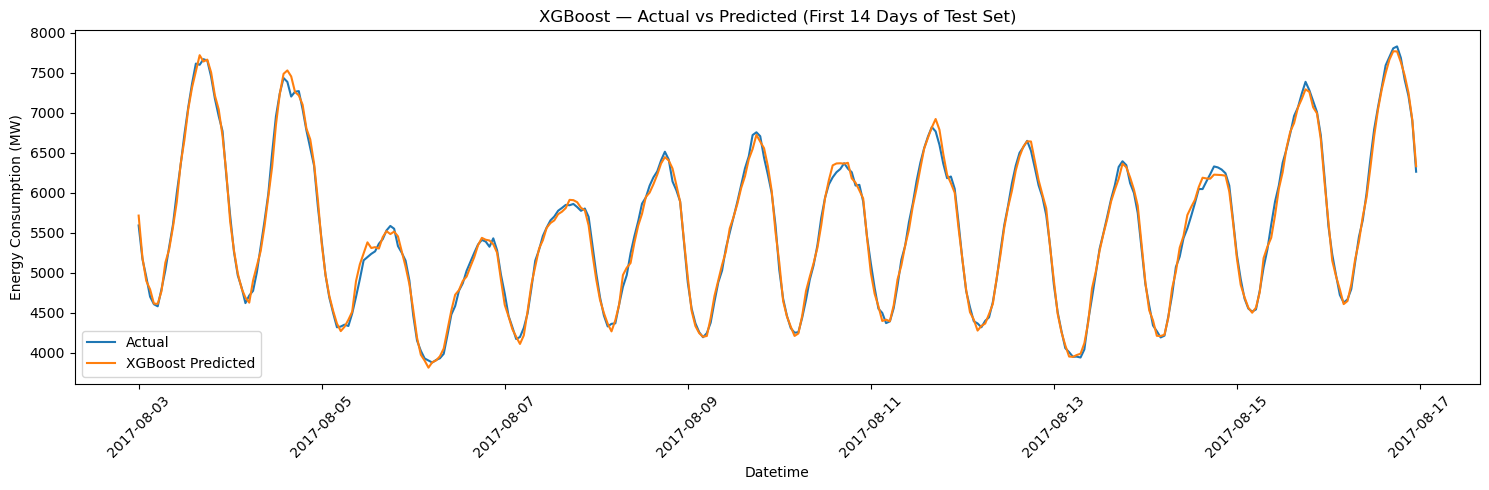

In [111]:
window = 24 * 14

plt.figure(figsize=(15, 5))
plt.plot(xgb_result['Datetime'][:window], xgb_result['Actual'][:window], label='Actual')
plt.plot(xgb_result['Datetime'][:window], xgb_result['Predicted'][:window], label='XGBoost Predicted')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title('XGBoost — Actual vs Predicted (First 14 Days of Test Set)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### XGBoost — Feature Importance

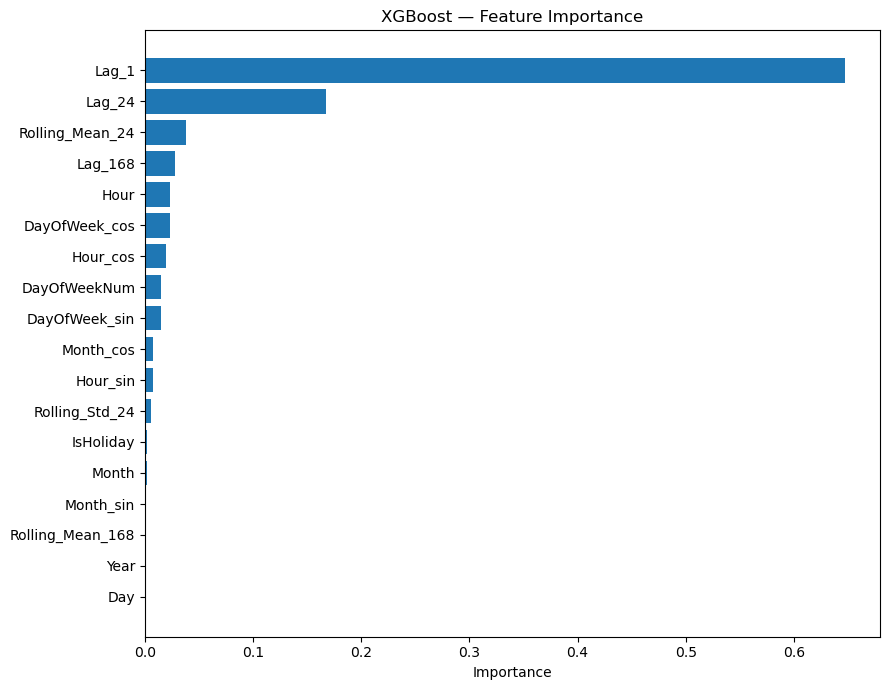

Lag_1               0.647312
Lag_24              0.167620
Rolling_Mean_24     0.037897
Lag_168             0.027797
Hour                0.022756
DayOfWeek_cos       0.022578
Hour_cos            0.019511
DayOfWeekNum        0.014933
DayOfWeek_sin       0.014538
Month_cos           0.006971
Hour_sin            0.006872
Rolling_Std_24      0.005293
IsHoliday           0.001629
Month               0.001354
Month_sin           0.001114
Rolling_Mean_168    0.000951
Year                0.000543
Day                 0.000334
dtype: float32

In [112]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(xgb_importance.index, xgb_importance.values)
plt.xlabel('Importance')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

xgb_importance.sort_values(ascending=False)

### XGBoost Insight
### The model relies most heavily on `Lag_1` (previous hour's consumption) and `Lag_24` (same hour, previous day), which matches the strong daily seasonality found during EDA. `Hour`, `Hour_cos` and `DayOfWeekNum` also contribute meaningfully, confirming that time-of-day and day-of-week are important drivers of consumption.

## 17. LightGBM Model

In [115]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)

lgbm_result = pd.DataFrame({
    'Datetime': ml_test['Datetime'].values,
    'Actual': y_test.values,
    'Predicted': lgbm_pred
})

lgbm_result.head(10)

,Datetime,Actual,Predicted
0,2017-08-03 00:00:00,5591.0,5692.087143
1,2017-08-03 01:00:00,5170.0,5176.067457
2,2017-08-03 02:00:00,4948.0,4882.667388
3,2017-08-03 03:00:00,4700.0,4763.841858
4,2017-08-03 04:00:00,4606.0,4602.121318
5,2017-08-03 05:00:00,4580.0,4627.964369
6,2017-08-03 06:00:00,4797.0,4759.881864
7,2017-08-03 07:00:00,5030.0,5124.393536
8,2017-08-03 08:00:00,5322.0,5282.079674
9,2017-08-03 09:00:00,5602.0,5598.039249


In [116]:
lgbm_mae, lgbm_rmse, lgbm_mape = evaluate(lgbm_result['Actual'], lgbm_result['Predicted'])

print("LightGBM Results")
print("-----------------")
print("MAE  :", lgbm_mae)
print("RMSE :", lgbm_rmse)
print("MAPE :", lgbm_mape, "%")

lgbm_results = {'Model': 'LightGBM', 'MAE': lgbm_mae, 'RMSE': lgbm_rmse, 'MAPE': lgbm_mape}
lgbm_results

LightGBM Results
-----------------
MAE  : 58.064343382905356
RMSE : 77.27619051357605
MAPE : 1.0045934161000576 %


{'Model': 'LightGBM',
 'MAE': 58.064343382905356,
 'RMSE': np.float64(77.27619051357605),
 'MAPE': np.float64(1.0045934161000576)}

### Actual vs Predicted — LightGBM (first 14 days of the test set)

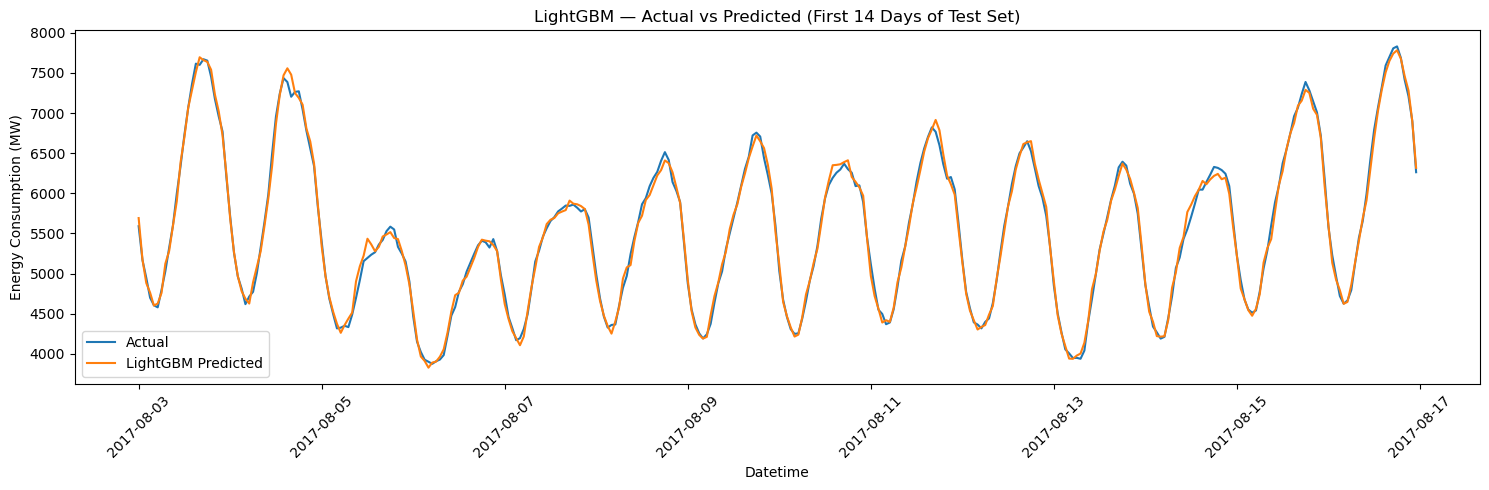

In [117]:
plt.figure(figsize=(15, 5))
plt.plot(lgbm_result['Datetime'][:window], lgbm_result['Actual'][:window], label='Actual')
plt.plot(lgbm_result['Datetime'][:window], lgbm_result['Predicted'][:window], label='LightGBM Predicted')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title('LightGBM — Actual vs Predicted (First 14 Days of Test Set)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Lightgbm-Important feature

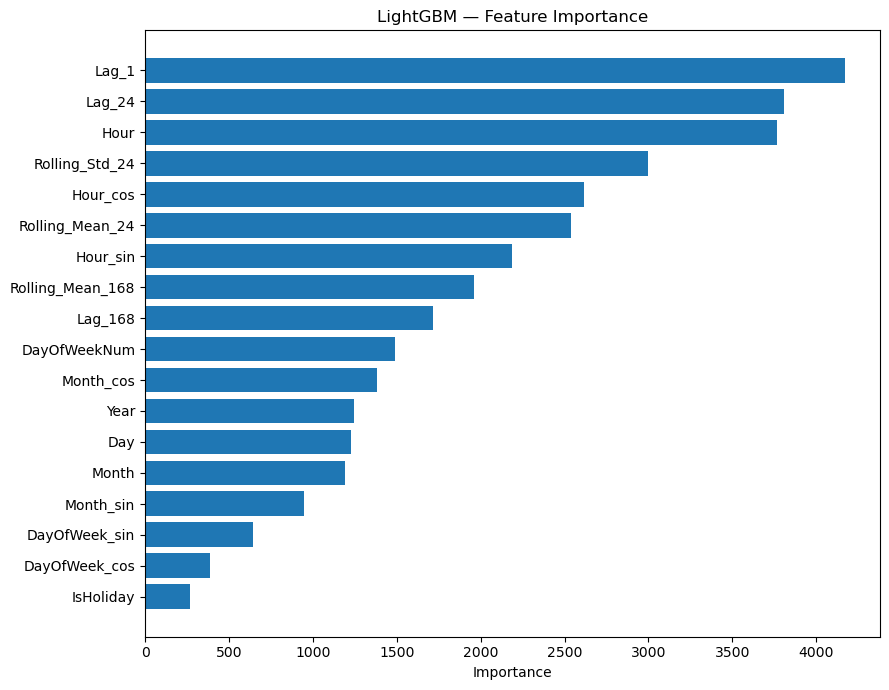

Lag_1               4172
Lag_24              3806
Hour                3769
Rolling_Std_24      2999
Hour_cos            2617
Rolling_Mean_24     2536
Hour_sin            2190
Rolling_Mean_168    1962
Lag_168             1715
DayOfWeekNum        1488
Month_cos           1382
Year                1246
Day                 1228
Month               1194
Month_sin            950
DayOfWeek_sin        645
DayOfWeek_cos        386
IsHoliday            269
dtype: int32

In [118]:
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
plt.barh(lgbm_importance.index, lgbm_importance.values)
plt.xlabel('Importance')
plt.title('LightGBM — Feature Importance')
plt.tight_layout()
plt.show()

lgbm_importance.sort_values(ascending=False)

## 18. Updated Model Comparison — All Models

In [119]:
all_model_comparison = pd.DataFrame([
    seasonal_naive_results,
    ses_results,
    holt_results,
    hw_results,
    xgb_results,
    lgbm_results
])

all_model_comparison.sort_values('MAPE').reset_index(drop=True)

,Model,MAE,RMSE,MAPE
0,XGBoost,5.712374e+01,7.709397e+01,0.989008
1,LightGBM,5.806434e+01,7.727619e+01,1.004593
2,Seasonal Naive,3.826808e+02,5.013514e+02,6.663336
3,Holt-Winters,9.491081e+02,1.177033e+03,16.950369
4,Simple Exponential Smoothing,9.458932e+02,1.135175e+03,18.264782
5,Holt's Linear Trend,1.957535e+06,2.260507e+06,34998.128512


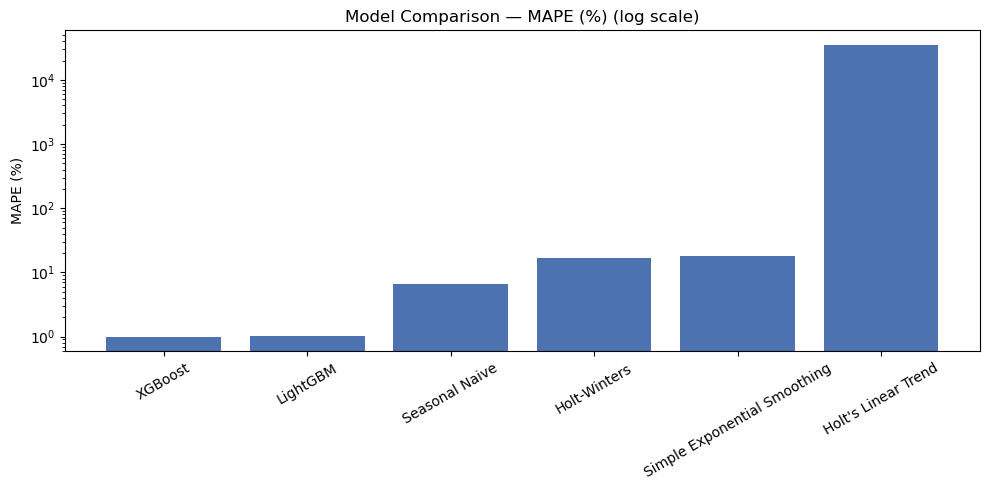

Best performing model: XGBoost


In [120]:
sorted_comp = all_model_comparison.sort_values('MAPE')

plt.figure(figsize=(10, 5))
plt.bar(sorted_comp['Model'], sorted_comp['MAPE'], color='#4C72B0')
plt.ylabel('MAPE (%)')
plt.title('Model Comparison — MAPE (%) (log scale)')
plt.yscale('log')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

best_model_name = sorted_comp.iloc[0]['Model']
print("Best performing model:", best_model_name)

### Model Comparison Insight
### Adding lag and rolling features lets the gradient boosting models directly use recent actual consumption, which the purely statistical models above cannot do. As a result, XGBoost and LightGBM cut the test MAPE from ~6.7% (Seasonal Naive, the previous best model) down to roughly 1%, a large improvement in forecast accuracy.

## 19. 30-Day Forecast using the Best ML Model
### We now generate a 720-hour (30-day) forecast the same way as the Seasonal Naive forecast above, but using the best-performing model (by MAPE). Since lag/rolling features need past values, the forecast is generated recursively: each predicted hour is fed back in as history for later hours.

In [121]:
best_model = xgb_model if best_model_name == 'XGBoost' else lgbm_model

history = ml_df[['Datetime', 'PJMW_MW']].copy().set_index('Datetime')['PJMW_MW']

future_dates_ml = pd.date_range(
    start=history.index.max() + pd.Timedelta(hours=1),
    periods=720,
    freq='h'
)

future_holidays = cal.holidays(start=future_dates_ml.min(), end=future_dates_ml.max())

buffer = history.copy()
ml_forecast_values = []

for ts in future_dates_ml:
    hour = ts.hour
    day = ts.day
    month = ts.month
    year = ts.year
    dow = ts.dayofweek
    is_holiday = int(ts.normalize() in future_holidays)

    row = {
        'Hour': hour,
        'Day': day,
        'Month': month,
        'Year': year,
        'DayOfWeekNum': dow,
        'IsHoliday': is_holiday,
        'Hour_sin': np.sin(2 * np.pi * hour / 24),
        'Hour_cos': np.cos(2 * np.pi * hour / 24),
        'Month_sin': np.sin(2 * np.pi * month / 12),
        'Month_cos': np.cos(2 * np.pi * month / 12),
        'DayOfWeek_sin': np.sin(2 * np.pi * dow / 7),
        'DayOfWeek_cos': np.cos(2 * np.pi * dow / 7),
        'Lag_1': buffer.iloc[-1],
        'Lag_24': buffer.iloc[-24],
        'Lag_168': buffer.iloc[-168],
        'Rolling_Mean_24': buffer.iloc[-24:].mean(),
        'Rolling_Mean_168': buffer.iloc[-168:].mean(),
        'Rolling_Std_24': buffer.iloc[-24:].std(),
    }

    X_future = pd.DataFrame([row])[FEATURES]
    pred_value = best_model.predict(X_future)[0]

    ml_forecast_values.append(pred_value)
    buffer.loc[ts] = pred_value

ml_forecast_30_days = pd.DataFrame({
    'Datetime': future_dates_ml,
    'Forecast_MW': ml_forecast_values
})

ml_forecast_30_days.head(24)

,Datetime,Forecast_MW
0,2018-08-03 01:00:00,5085.206055
1,2018-08-03 02:00:00,4819.419922
2,2018-08-03 03:00:00,4663.956543
3,2018-08-03 04:00:00,4563.372559
4,2018-08-03 05:00:00,4567.588867
5,2018-08-03 06:00:00,4758.249023
6,2018-08-03 07:00:00,5105.590820
7,2018-08-03 08:00:00,5383.011719
8,2018-08-03 09:00:00,5603.593750
9,2018-08-03 10:00:00,5802.044922


### Visualize the 30-day ML forecast

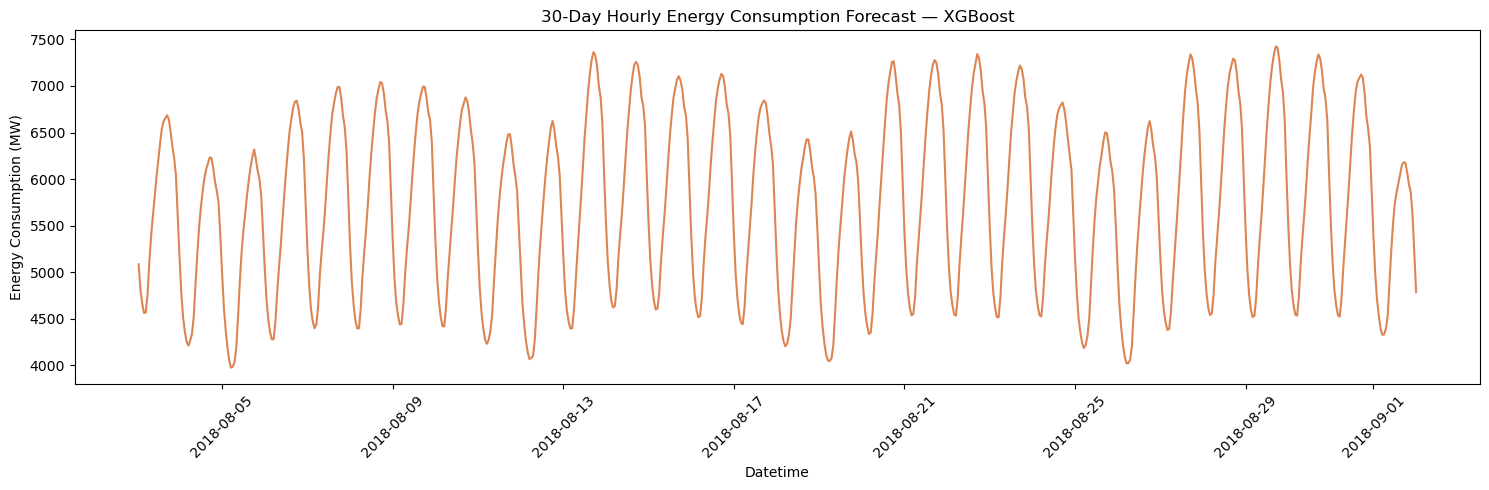

In [122]:
plt.figure(figsize=(15, 5))
plt.plot(ml_forecast_30_days['Datetime'], ml_forecast_30_days['Forecast_MW'], color='#DD8452')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title(f'30-Day Hourly Energy Consumption Forecast — {best_model_name}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [123]:
ml_forecast_30_days.to_excel(f'PJM_30_Day_Forecast_{best_model_name}.xlsx', index=False)
print(f"{best_model_name} 30-day forecast file saved successfully.")

XGBoost 30-day forecast file saved successfully.


In [124]:
print("30-Day Forecast Summary")
print("-----------------------")
print("Model          :", best_model_name)
print("Forecast Start :", ml_forecast_30_days['Datetime'].min())
print("Forecast End   :", ml_forecast_30_days['Datetime'].max())
print("Total Hours    :", len(ml_forecast_30_days))
print("Average MW     :", ml_forecast_30_days['Forecast_MW'].mean())
print("Minimum MW     :", ml_forecast_30_days['Forecast_MW'].min())
print("Maximum MW     :", ml_forecast_30_days['Forecast_MW'].max())

30-Day Forecast Summary
-----------------------
Model          : XGBoost
Forecast Start : 2018-08-03 01:00:00
Forecast End   : 2018-09-02 00:00:00
Total Hours    : 720
Average MW     : 5733.2
Minimum MW     : 3975.648193359375
Maximum MW     : 7425.05615234375


## XGBoost & LightGBM Summary
## Both gradient boosting models were trained using engineered time-based, lag, and rolling features and evaluated on the same one-year test split used for the statistical forecasting models. XGBoost achieved the lowest overall error among the evaluated models, with a MAPE of approximately 0.99%, narrowly outperforming LightGBM at approximately 1.00%. Both gradient boosting models substantially reduced prediction errors compared with Seasonal Naive, Holt-Winters, Simple Exponential Smoothing, and Holt's Linear Trend. The selected XGBoost model was subsequently used to generate the final 720-hour (30-day) electricity demand forecast, with an average predicted demand of 5733.20 MW, ranging from 3975.65 MW to 7425.06 MW.